# Pima Diabetes Classification (Thực nghiệm mô hình)

## Research Questions

1. Trong 4 mô hình LR/DT/RF/SVM, mô hình nào đạt **F1-score** cao nhất trên tập test sau khi xử lý mất cân bằng lớp?
2. Khi bổ sung đánh giá theo **ROC-AUC** và **PR-AUC**, thứ hạng mô hình có thay đổi so với chỉ dùng Accuracy/F1 không?
3. Các đặc trưng nào ảnh hưởng mạnh nhất tới dự đoán tiểu đường theo Random Forest (impurity importance và permutation importance)?

## Ôn tập (Review)

Trong phần preprocessing, dữ liệu đã được:
- Chia train/test theo chiến lược hold-out.
- Làm sạch các giá trị 0 phi lý ở cột y tế bằng median (fit trên train).
- Chuẩn hóa StandardScaler cho toàn bộ cột đầu vào.
- Lưu features train/test tại thư mục exps/feature1.

Mục tiêu ở notebook này:
- Huấn luyện 4 mô hình: Logistic Regression, Decision Tree, Random Forest, SVM.
- So sánh mô hình theo Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC.
- Tuning Random Forest bằng GridSearchCV.
- Lưu mô hình tốt nhất vào ../models/best_model.pkl.

## Khởi tạo thí nghiệm

### Khai báo thư viện

In [1]:
# Load libraries
import os
import random
import warnings

import joblib
import numpy as np
import pandas as pd
from IPython import display

from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance

try:
    from imblearn.over_sampling import SMOTE
except ImportError as err:
    raise ImportError('Vui long cai dat imbalanced-learn: pip install imbalanced-learn') from err

import matplotlib.pyplot as plt

%matplotlib inline
warnings.filterwarnings("ignore")

### Tham số thực nghiệm

In [2]:
params = {}

params["seed"] = 42
params["k_fold"] = 5

params["exps_dir"] = "../exps"
params["feature_dir"] = f'{params["exps_dir"]}/feature1'
params["train_feat_path"] = f'{params["feature_dir"]}/feat_standard.npz'
params["test_feat_path"] = f'{params["feature_dir"]}/feat_standard_test.npz'
params["selected_features_path"] = f'{params["feature_dir"]}/selected_features.npz'

params["model_save_path"] = "../models/best_model.pkl"
os.makedirs(os.path.dirname(params["model_save_path"]), exist_ok=True)

print("params:")
for k in params:
    print(f'+ {k}: {params[k]}')

random.seed(params["seed"])
os.environ["PYTHONHASHSEED"] = str(params["seed"])
np.random.seed(params["seed"])

params:
+ seed: 42
+ k_fold: 5
+ exps_dir: ../exps
+ feature_dir: ../exps/feature1
+ train_feat_path: ../exps/feature1/feat_standard.npz
+ test_feat_path: ../exps/feature1/feat_standard_test.npz
+ selected_features_path: ../exps/feature1/selected_features.npz
+ model_save_path: ../models/best_model.pkl


## Dữ liệu kiểm nghiệm (Validation/Test Dataset)

In [3]:
train_data = np.load(params["train_feat_path"])
test_data = np.load(params["test_feat_path"])

X_train = train_data["x_train"]
y_train = train_data["y_train"].astype(int)
X_test = test_data["x_test"]
y_test = test_data["y_test"].astype(int)
feature_names = np.load(params["selected_features_path"], allow_pickle=True)["selected_features"].tolist()

print(f'+ X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'+ X_test : {X_test.shape}, y_test : {y_test.shape}')
print('+ y_train distribution:')
print(pd.Series(y_train).value_counts().sort_index())
print('+ y_test distribution:')
print(pd.Series(y_test).value_counts().sort_index())
print('+ feature_names:')
print(feature_names)

+ X_train: (514, 8), y_train: (514,)
+ X_test : (254, 8), y_test : (254,)
+ y_train distribution:
0    335
1    179
Name: count, dtype: int64
+ y_test distribution:
0    165
1     89
Name: count, dtype: int64


## Huấn luyện mô hình baseline (4 thuật toán)

In [ ]:
from imblearn.pipeline import Pipeline

baseline_models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=params["seed"]),
    "DecisionTree": DecisionTreeClassifier(random_state=params["seed"]),
    "RandomForest": RandomForestClassifier(random_state=params["seed"]),
    "SVM": SVC(kernel="rbf", probability=True, random_state=params["seed"]),
}

kfold = KFold(n_splits=params["k_fold"], shuffle=True, random_state=params["seed"])

baseline_results = {
    "cv_acc_mean": {},
    "cv_acc_std": {},
    "models": {},
}

for model_name in baseline_models:
    model = baseline_models[model_name]
    
    # Tạo pipeline bọc SMOTE bên trong để tránh Data Leakage khi chạy CV
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=params["seed"])),
        ('model', model)
    ])
    
    # Chạy CV dùng dữ liệu gốc X_train, y_train chừa qua SMOTE
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring="f1")
    
    # Sau CV, fit lại model bằng pipeline qua SMOTE trên TOÀN BỘ tập train
    pipeline.fit(X_train, y_train)

    baseline_results["cv_acc_mean"][model_name] = cv_scores.mean()
    baseline_results["cv_acc_std"][model_name] = cv_scores.std()
    
    # Lưu lại pipeline đã train như là baseline model chính thức
    baseline_results["models"][model_name] = pipeline

    print(f'Baseline [{model_name}]')
    print(f'+ cv_f1_mean = {cv_scores.mean():.4f}')
    print(f'+ cv_f1_std  = {cv_scores.std():.4f}')

cv_df = pd.DataFrame({
    "Model": list(baseline_results["cv_acc_mean"].keys()),
    "CV_F1_Mean": [baseline_results["cv_acc_mean"][m] for m in baseline_results["cv_acc_mean"]],
    "CV_F1_Std": [baseline_results["cv_acc_std"][m] for m in baseline_results["cv_acc_std"]],
}).sort_values("CV_F1_Mean", ascending=False).reset_index(drop=True)

print("\nBảng so sánh baseline (cross-validation không rò rỉ dữ liệu):")
display.display(cv_df.round(4))

## Đánh giá trên tập test (Baseline)

So sánh theo 6 chỉ số: Accuracy, Precision, Recall, F1-score, ROC-AUC, PR-AUC.

In [6]:
def evaluate_model(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_eval)
    else:
        y_score = y_pred
    return {
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1": f1_score(y_eval, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_eval, y_score),
        "PR_AUC": average_precision_score(y_eval, y_score),
    }

baseline_test_rows = []
for model_name, model in baseline_results["models"].items():
    scores = evaluate_model(model, X_test, y_test)
    baseline_test_rows.append({"Model": model_name, **scores})

baseline_test_df = pd.DataFrame(baseline_test_rows).sort_values("F1", ascending=False).reset_index(drop=True)
print("Bảng so sánh mô hình baseline trên test:")
display.display(baseline_test_df.round(4))

Bảng so sánh mô hình baseline trên test:


,Model,Accuracy,Precision,Recall,F1
0,RandomForest,0.7598,0.6944,0.5618,0.6211
1,DecisionTree,0.7087,0.5824,0.5955,0.5889
2,LogisticRegression,0.7402,0.6620,0.5281,0.5875
3,SVM,0.7480,0.6923,0.5056,0.5844


## ROC Curve (so sánh 4 mô hình baseline)

In [7]:
plt.figure(figsize=(8, 6))

for model_name, model in baseline_results["models"].items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = model.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_value = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

GridSearchCV - RandomForest
+ best_score (cv f1): 0.6486
+ best_params      : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


## Tuning Random Forest (GridSearchCV)

In [ ]:
rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=params["seed"])),
    ('model', RandomForestClassifier(random_state=params["seed"]))
])

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    scoring="f1",
    cv=kfold,
    n_jobs=-1,
    refit=True,
)

# Chạy grid search trên tập train GỐC thông qua pipeline chống data leakage
rf_grid.fit(X_train, y_train)

# Lấy lại mô hình Random Forest tốt nhất ra (phần 'model' của best pipeline)
rf_best = rf_grid.best_estimator_
rf_best_model = rf_best.named_steps['model']

print("GridSearchCV - RandomForest")
print(f'+ best_score (cv f1): {rf_grid.best_score_:.4f}')
print(f'+ best_params      : {rf_grid.best_params_}')

## Feature Importance (Random Forest)

In [ ]:
rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_best_model.feature_importances_,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

perm = permutation_importance(
    rf_best,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=params["seed"],
)
perm_df = pd.DataFrame({
    "Feature": feature_names,
    "PermutationImportance": perm.importances_mean,
}).sort_values("PermutationImportance", ascending=False).reset_index(drop=True)

display.display(rf_importance_df.round(4))
display.display(perm_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(rf_importance_df["Feature"][::-1], rf_importance_df["Importance"][::-1], color="steelblue")
axes[0].set_title("RF Impurity Feature Importance")
axes[0].set_xlabel("Importance")

axes[1].barh(perm_df["Feature"][::-1], perm_df["PermutationImportance"][::-1], color="darkorange")
axes[1].set_title("Permutation Importance (F1)")
axes[1].set_xlabel("Mean Importance")

plt.tight_layout()
plt.show()

Bảng so sánh cuối cùng trên test:


,Model,Accuracy,Precision,Recall,F1
0,RandomForest_Tuned,0.7559,0.6709,0.5955,0.6310
1,RandomForest,0.7598,0.6944,0.5618,0.6211
2,DecisionTree,0.7087,0.5824,0.5955,0.5889
3,LogisticRegression,0.7402,0.6620,0.5281,0.5875
4,SVM,0.7480,0.6923,0.5056,0.5844


## So sánh mô hình sau tuning

In [ ]:
final_models = dict(baseline_results["models"])
final_models["RandomForest_Tuned"] = rf_best

final_rows = []
for model_name, model in final_models.items():
    scores = evaluate_model(model, X_test, y_test)
    final_rows.append({"Model": model_name, **scores})

final_df = pd.DataFrame(final_rows).sort_values(["F1", "ROC_AUC", "Accuracy"], ascending=False).reset_index(drop=True)

print("Bảng so sánh cuối cùng trên test:")
display.display(final_df.round(4))

## Lưu mô hình tốt nhất

Saved best model:
+ model_name: RandomForest_Tuned
+ save_path : ../models/best_model.pkl

Confusion matrix (best model):


array([[139,  26],
       [ 36,  53]])

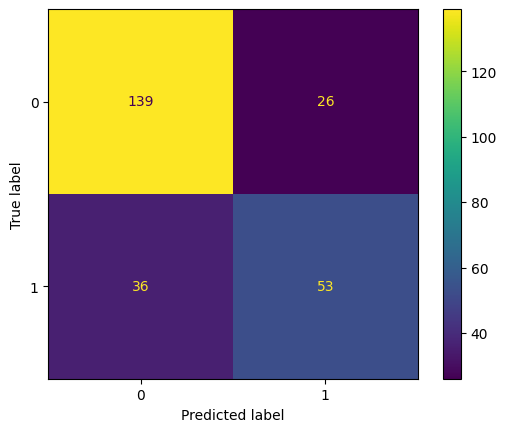

In [9]:
best_model_name = final_df.iloc[0]["Model"]
best_model = final_models[best_model_name]

joblib.dump(best_model, params["model_save_path"])

print("Saved best model:")
print(f'+ model_name: {best_model_name}')
print(f'+ save_path : {params["model_save_path"]}')

# Hiển thị confusion matrix của mô hình tốt nhất
best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_pred)
print("\nConfusion matrix (best model):")
display.display(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.show()

# Kết thúc